# Milestone 2: Initial Implementation — Spotify Audio Features & Song Clusters
**Sarbani Adhikari** | CS 4412

Note: this is the cleaned up version. Figures save to `../outputs/figures/` so they work with the repo structure.
Run this from the `notebooks/` folder.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')


## 1. Loading the data


In [2]:
df = pd.read_csv('../data/dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

print(df.shape)
print(df.columns.tolist())


(114000, 20)
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [5]:
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


114k tracks, 20 columns. The audio features are the ones we care about for clustering.


## 2. EDA

Looking at distributions, correlations, and how genres differ in audio features.


### distributions of audio features


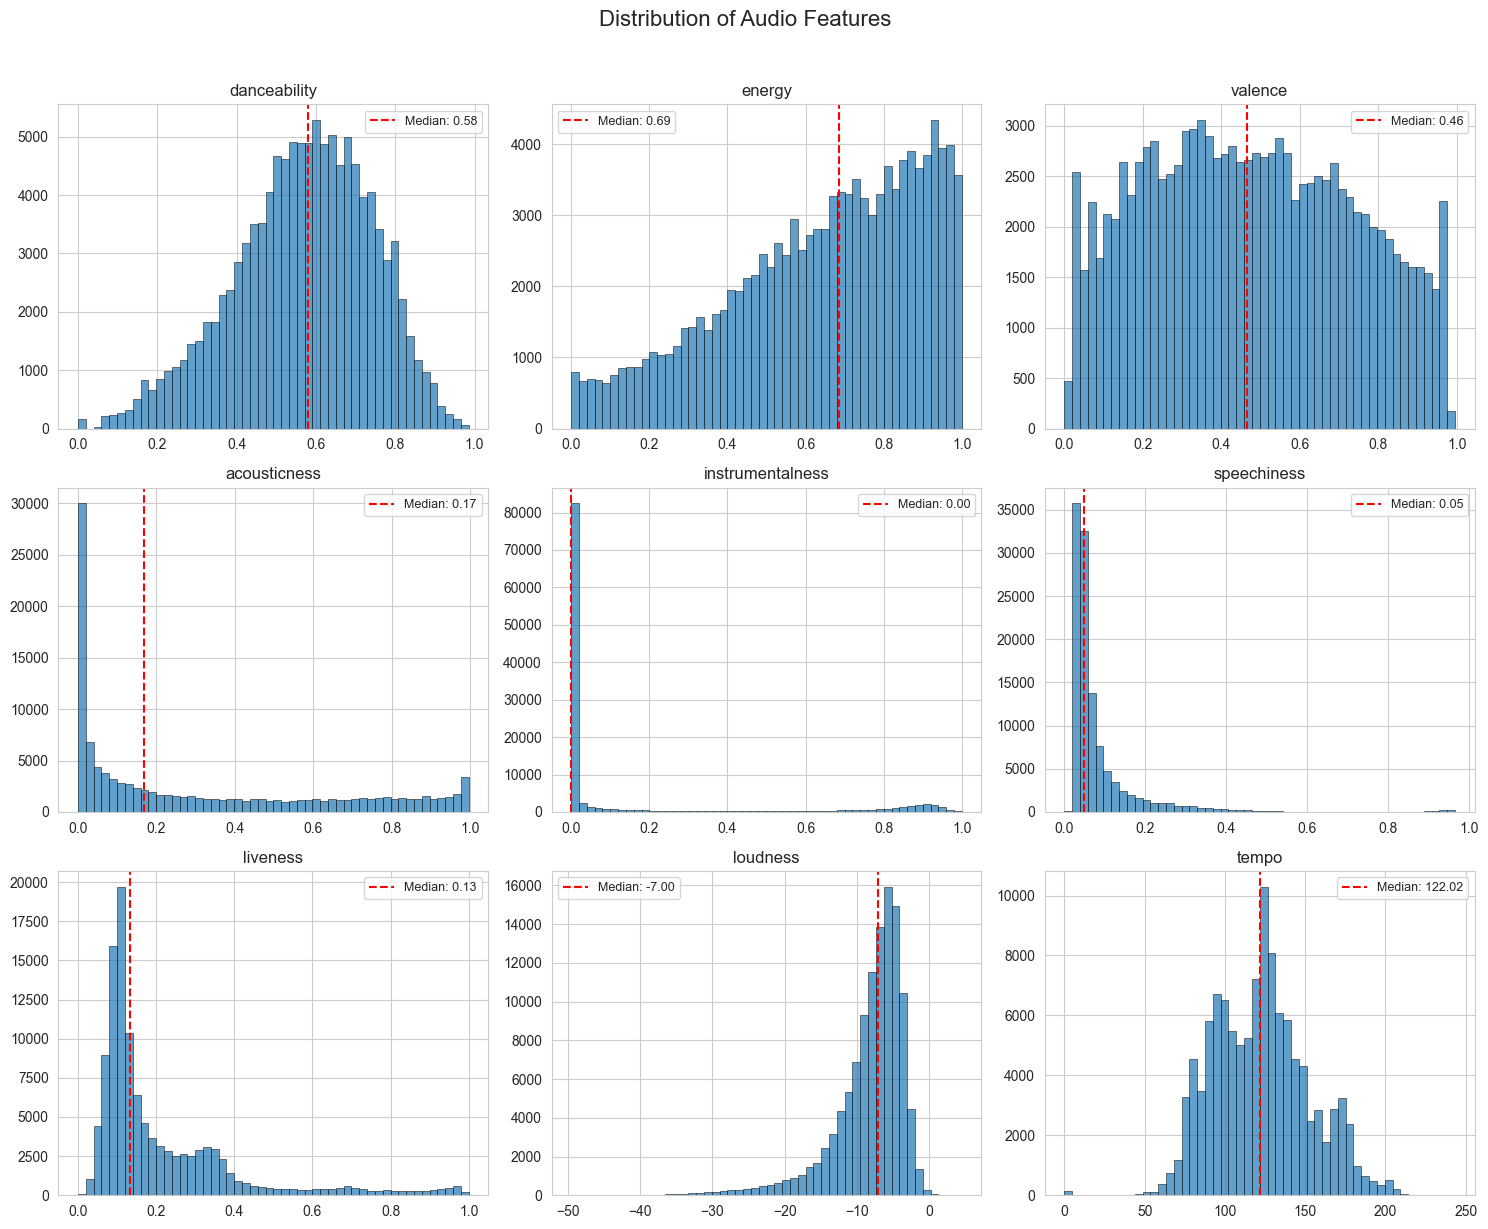

In [6]:
audioFeatures = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, feat in enumerate(audioFeatures):
    ax = axes[i // 3, i % 3]
    df[feat].dropna().hist(bins=50, ax=ax, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(feat)
    median_val = df[feat].median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Audio Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


danceability and energy look pretty normal. instrumentalness and speechiness are super skewed right — most songs have vocals. acousticness looks kind of bimodal which is interesting, songs are either acoustic or not.


### box plots to check for outliers


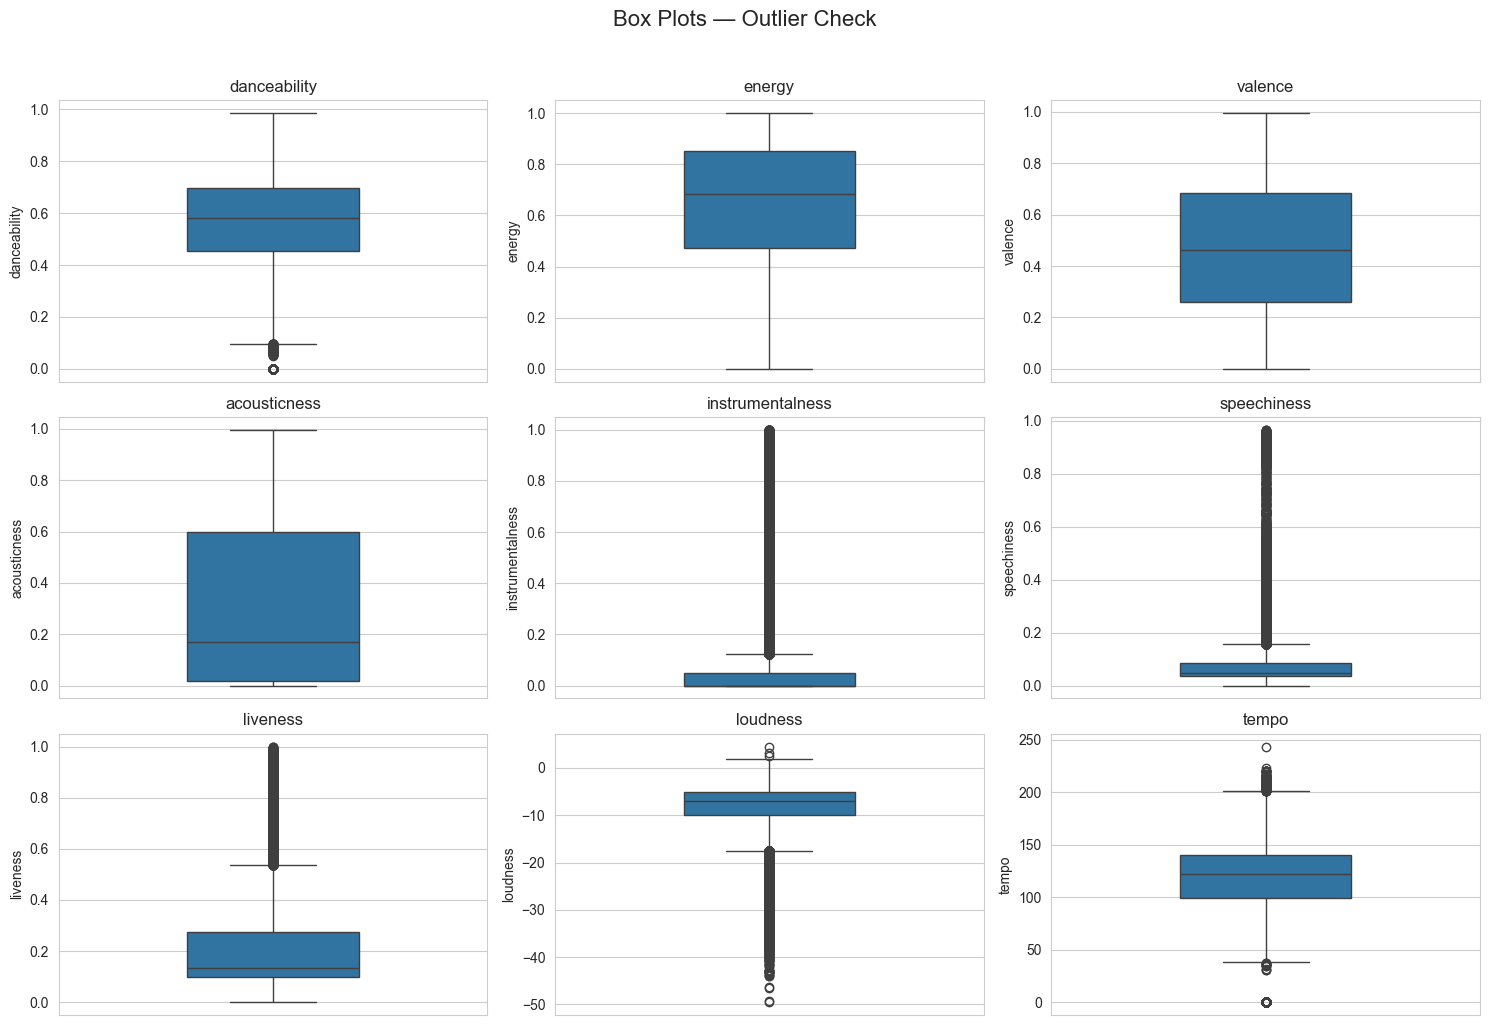

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, feat in enumerate(audioFeatures):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, y=feat, ax=ax, width=0.4)
    ax.set_title(feat)

plt.suptitle('Box Plots — Outlier Check', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


speechiness and liveness have outliers but those are probably just spoken word tracks and live recordings. not actual errors so keeping them.


### correlation matrix


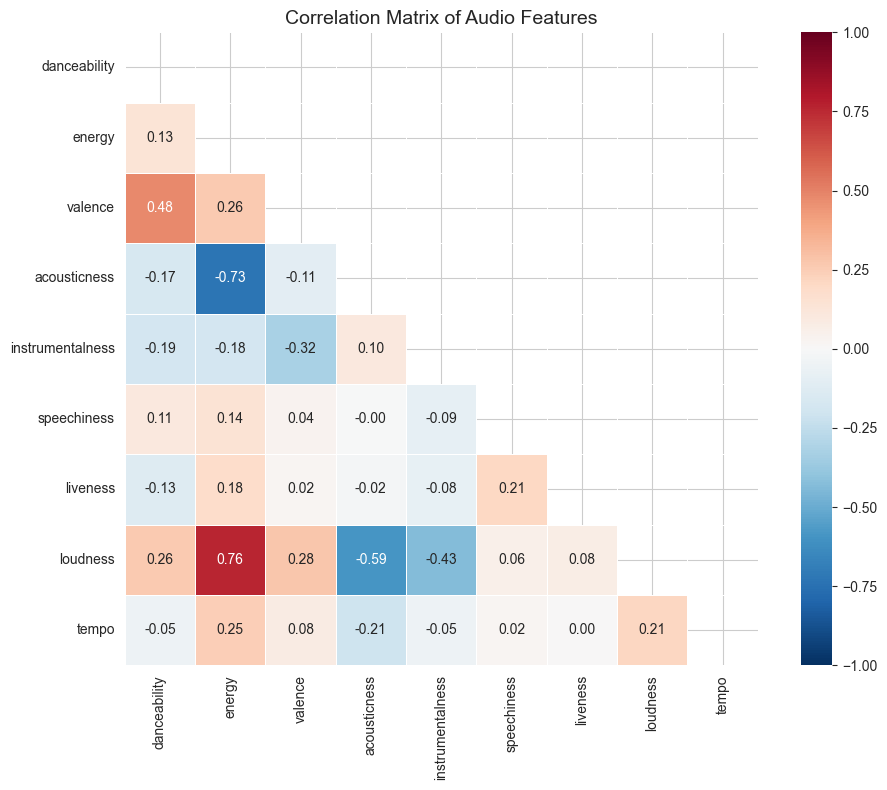

In [8]:
corr = df[audioFeatures].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix of Audio Features', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


energy and loudness are strongly correlated (makes sense). energy and acousticness are negatively correlated. most other features are pretty independent which is good for clustering.


### scatter plots for interesting pairs


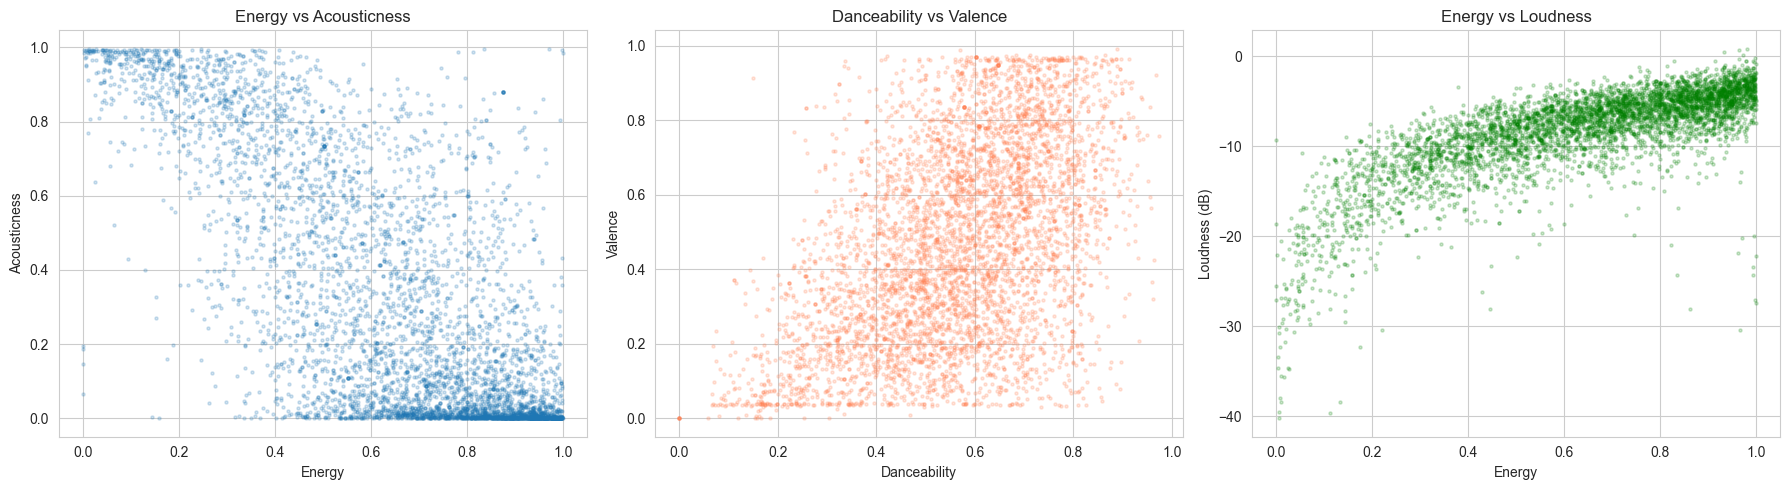

In [9]:
sample_df = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(sample_df['energy'], sample_df['acousticness'], alpha=0.2, s=5)
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Acousticness')
axes[0].set_title('Energy vs Acousticness')

axes[1].scatter(sample_df['danceability'], sample_df['valence'], alpha=0.2, s=5, c='coral')
axes[1].set_xlabel('Danceability')
axes[1].set_ylabel('Valence')
axes[1].set_title('Danceability vs Valence')

axes[2].scatter(sample_df['energy'], sample_df['loudness'], alpha=0.2, s=5, c='green')
axes[2].set_xlabel('Energy')
axes[2].set_ylabel('Loudness (dB)')
axes[2].set_title('Energy vs Loudness')

plt.tight_layout()
plt.savefig('../outputs/figures/fig4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


energy vs acousticness has a clear inverse pattern. energy vs loudness is basically linear. danceability vs valence has a slight positive trend but lots of scatter.


### genre profiles


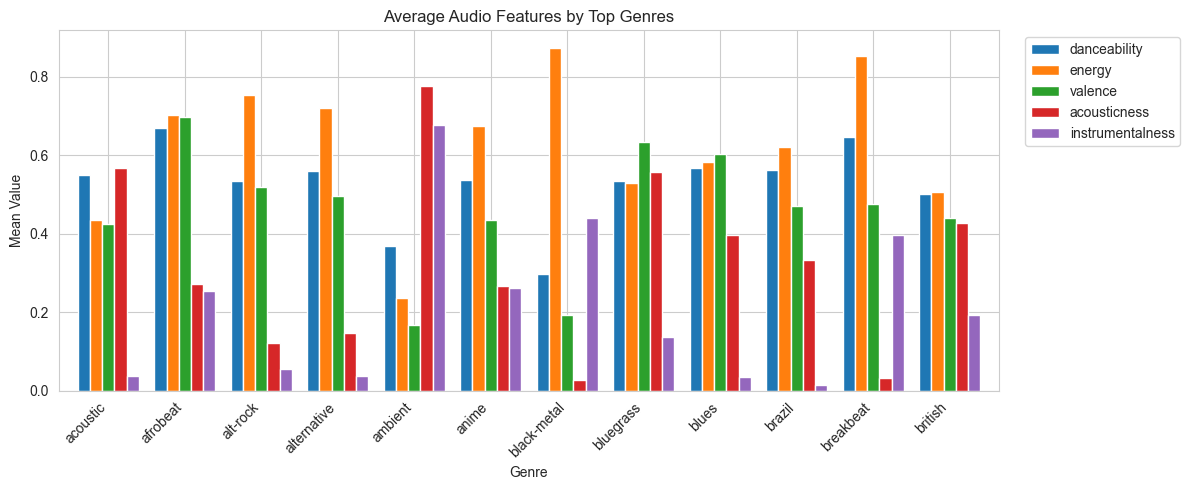

In [10]:
topGenres = df['track_genre'].value_counts().head(12).index.tolist()
df_top = df[df['track_genre'].isin(topGenres)]

# print(df['track_genre'].value_counts().head(20))

fig, ax = plt.subplots(figsize=(12, 5))
genreMeans = df_top.groupby('track_genre')[['danceability', 'energy', 'valence', 
                                               'acousticness', 'instrumentalness']].mean()
genreMeans.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Audio Features by Top Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('Mean Value')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/fig5_genre_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


genres do have different profiles but there's a lot of overlap between pop/dance/electronic. classical and metal are the most distinct. this makes me think clustering on audio features will find groups that don't match genre labels exactly.


### popularity by genre


C:\Users\Noah\AppData\Local\Temp\ipykernel_14312\4182923642.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


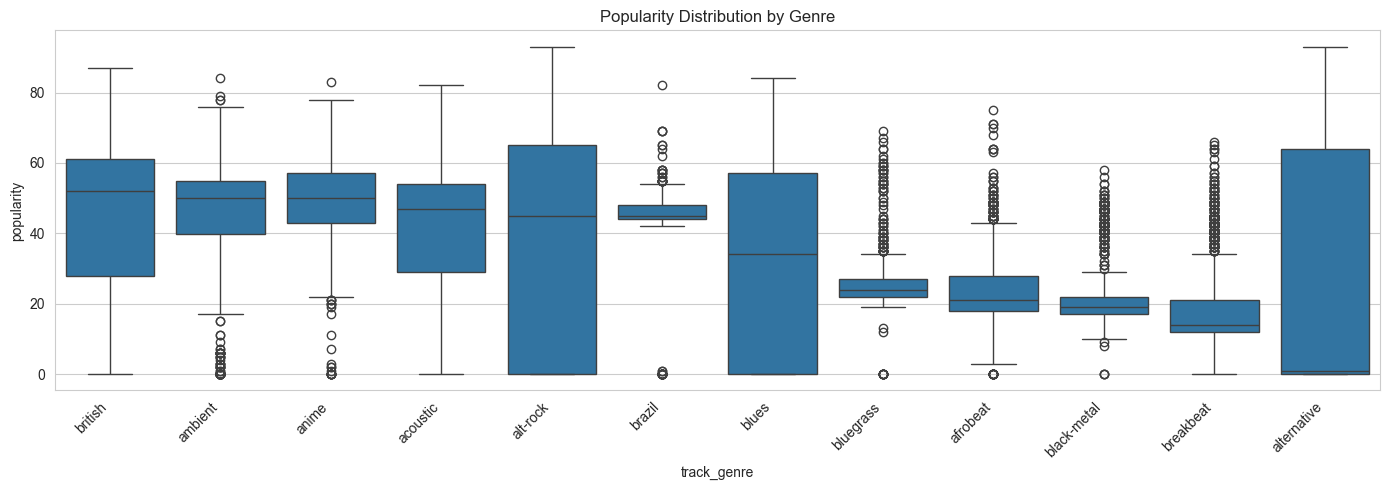

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
genreOrder = df_top.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top, x='track_genre', y='popularity', order=genreOrder, ax=ax)
ax.set_title('Popularity Distribution by Genre')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/fig6_popularity.png', dpi=150, bbox_inches='tight')
plt.show()


popularity is all over the place within each genre. not really driven by genre alone.


### track duration


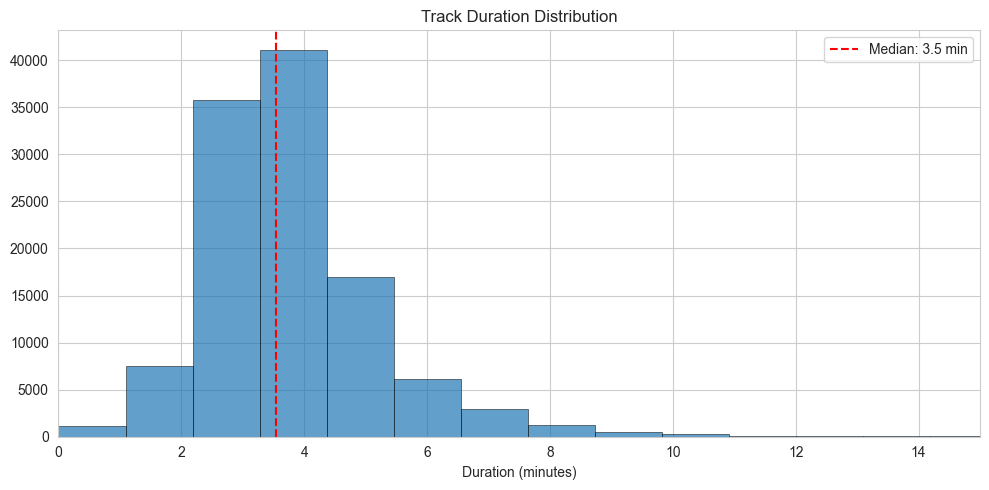

In [12]:
dur_minutes = df['duration_ms'] / 60000
# print(dur_minutes.describe())

fig, ax = plt.subplots(figsize=(10, 5))
dur_minutes.hist(bins=80, ax=ax, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(dur_minutes.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {dur_minutes.median():.1f} min')
ax.set_title('Track Duration Distribution')
ax.set_xlabel('Duration (minutes)')
ax.set_xlim(0, 15)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/fig7_duration.png', dpi=150, bbox_inches='tight')
plt.show()


most songs are around 3-4 minutes. some really long ones but that's fine.


## 3. Preprocessing


### missing values


In [13]:
print(df.isnull().sum())
print()
print(f"rows with any null: {df.isnull().any(axis=1).sum()}")


track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

rows with any null: 1


In [14]:
rows_before = len(df)
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"dropped {rows_before - len(df)} rows with missing metadata")
print(f"shape now: {df.shape}")


dropped 1 rows with missing metadata
shape now: (113999, 20)


only a rows had missing artist/album/track names. no missing audio features at all.


### duplicates


In [15]:
print(f"exact duplicate rows: {df.duplicated().sum()}")
print(f"duplicate track_ids: {df.duplicated(subset=['track_id']).sum()}")


exact duplicate rows: 450
duplicate track_ids: 24259


In [16]:
df = df.drop_duplicates(subset=['track_id'], keep='first').reset_index(drop=True)
print(f"shape after dedup: {df.shape}")


shape after dedup: (89740, 20)


In [17]:
# checking if any tracks show up under multiple genres
trackGenreCounts = df.groupby('track_id')['track_genre'].nunique()
print(f"tracks in multiple genres: {(trackGenreCounts > 1).sum()}")


tracks in multiple genres: 0


~24k duplicate track ids, probably tracks listed under multiple genres. removed them. after dedup no tracks appear in multiple genres anymore since we kept first occurrence.


### outlier check


In [18]:
for feat in audioFeatures:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    print(f"{feat}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%)")


danceability: 474 outliers (0.53%)
energy: 0 outliers (0.00%)
valence: 0 outliers (0.00%)
acousticness: 0 outliers (0.00%)
instrumentalness: 19613 outliers (21.86%)
speechiness: 10644 outliers (11.86%)
liveness: 6981 outliers (7.78%)
loudness: 5026 outliers (5.60%)
tempo: 514 outliers (0.57%)


keeping all outliers since they're legit (live tracks, spoken word, etc).


### quick sanity check on value ranges


In [19]:
bounded = ['danceability', 'energy', 'valence', 'acousticness', 
           'instrumentalness', 'speechiness', 'liveness']
for feat in bounded:
    bad = ((df[feat] < 0) | (df[feat] > 1)).sum()
    if bad > 0:
        print(f"WARNING: {feat} has {bad} values outside [0,1]")
    # else:
    #     print(f"{feat} ok")

print(f"loudness range: {df['loudness'].min():.1f} to {df['loudness'].max():.1f}")
print(f"tempo range: {df['tempo'].min():.1f} to {df['tempo'].max():.1f}")
print(f"duration range: {df['duration_ms'].min()} to {df['duration_ms'].max()}")


loudness range: -49.5 to 4.5
tempo range: 0.0 to 243.4
duration range: 8586 to 5237295


everything looks clean. no weird values.


## 4. Transformation

standardizing features so clustering works properly


In [20]:
clustering_features = ['danceability', 'energy', 'valence', 'acousticness', 
                       'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

X = df[clustering_features].copy()
print(f"shape: {X.shape}")
print(f"any nulls: {X.isnull().sum().sum()}")


shape: (89740, 9)
any nulls: 0


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print(pd.DataFrame(X_scaled, columns=clustering_features).describe())


z-score standardized everything. without this, loudness and tempo would dominate since they're on way bigger scales than the 0-1 features.


### PCA


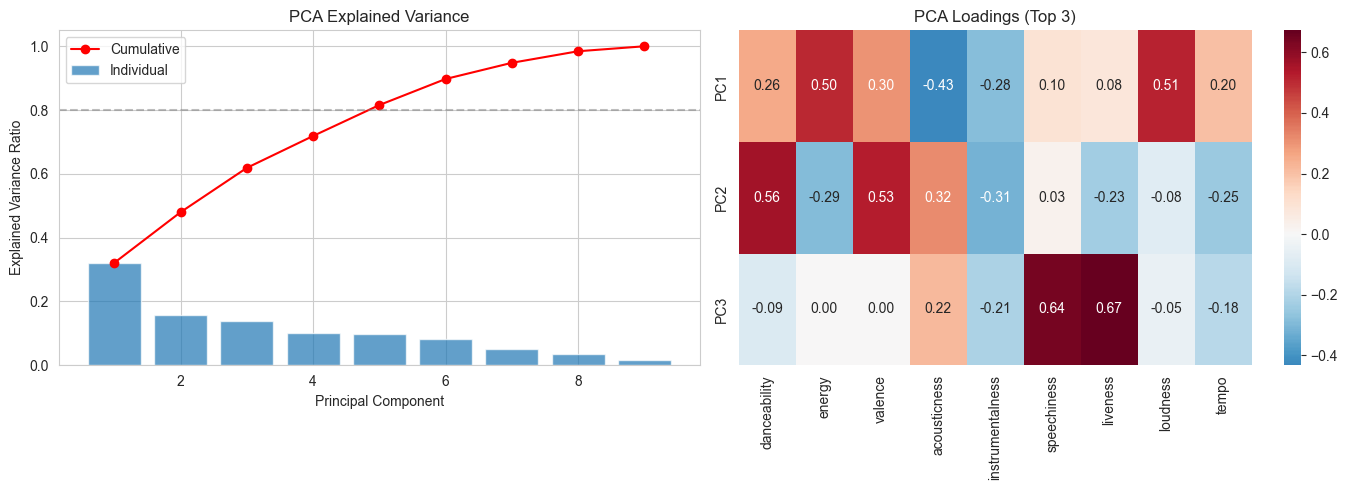

first 2 PCs: 47.99%
first 3 PCs: 61.88%


In [22]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumVar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(cumVar) + 1), cumVar, 'ro-', label='Cumulative')
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()

loadings = pd.DataFrame(pca_full.components_[:3], 
                        columns=clustering_features,
                        index=['PC1', 'PC2', 'PC3'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('PCA Loadings (Top 3)')

plt.tight_layout()
plt.savefig('../outputs/figures/fig8_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"first 2 PCs: {cumVar[1]:.2%}")
print(f"first 3 PCs: {cumVar[2]:.2%}")


PC1 is basically an acoustic vs produced axis (energy/loudness vs acousticness). PC2 picks up danceability and valence stuff. need quite a few components to get to 80% which means the data is genuinely multidimensional.


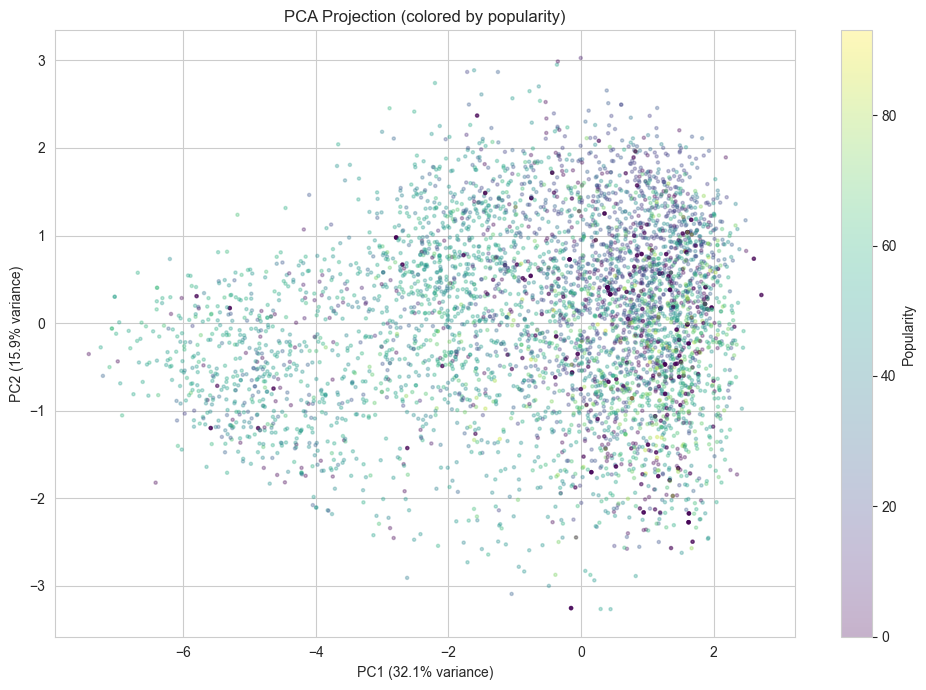

In [23]:
pca2d = PCA(n_components=2)
X_pca = pca2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:5000, 0], X_pca[:5000, 1], 
                     c=df['popularity'].values[:5000], cmap='viridis', 
                     alpha=0.3, s=5)
plt.colorbar(scatter, ax=ax, label='Popularity')
ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Projection (colored by popularity)')
plt.tight_layout()
plt.savefig('../outputs/figures/fig9_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


you can kind of see structure here. popularity doesn't seem to cluster in any one area though.


## 5. Clustering — K-Means

### finding the right k


In [24]:
K_range = range(2, 11)
inertias = []
sil_scores = []

np.random.seed(42)
sampleIdx = np.random.choice(len(X_scaled), size=15000, replace=False)
X_sample = X_scaled[sampleIdx]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=42))
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}")


k=2: inertia=105102, silhouette=0.2646
k=3: inertia=93244, silhouette=0.1632
k=4: inertia=83946, silhouette=0.1707
k=5: inertia=75817, silhouette=0.1784
k=6: inertia=68954, silhouette=0.1880
k=7: inertia=62874, silhouette=0.1956
k=8: inertia=59442, silhouette=0.1796
k=9: inertia=56247, silhouette=0.1824
k=10: inertia=53821, silhouette=0.1697


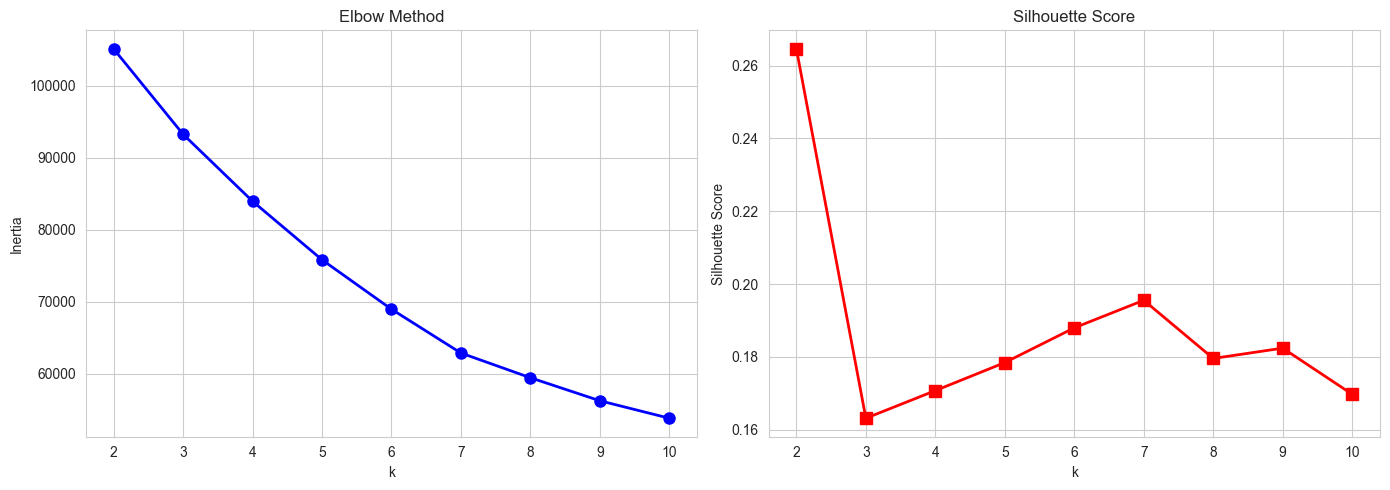

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/figures/fig10_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


elbow is around 4-5. silhouette is highest at k=2 but that's too few to be interesting. going with k=5.


### running k=5


In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"silhouette: {silhouette_score(X_scaled, df['cluster'], sample_size=10000, random_state=42):.4f}")
print(f"davies-bouldin: {davies_bouldin_score(X_scaled, df['cluster']):.4f}")
print()
print(df['cluster'].value_counts().sort_index())


silhouette: 0.1774
davies-bouldin: 1.5165

cluster
0    26856
1    20830
2    33656
3     7296
4     1102
Name: count, dtype: int64


### clusters in PCA space


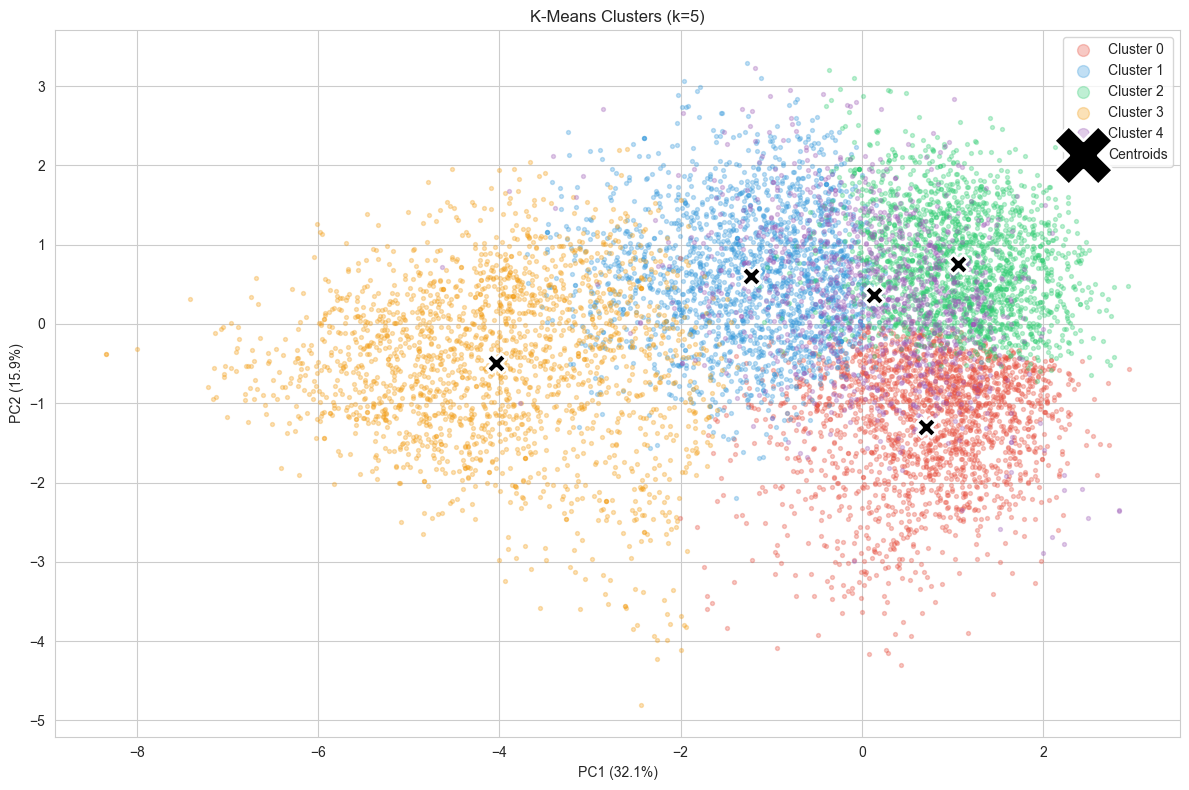

In [27]:
X_pca_all = pca2d.transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
clusterColors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i in range(5):
    mask = df['cluster'] == i
    idx = np.where(mask)[0]
    if len(idx) > 2000:
        idx = np.random.choice(idx, 2000, replace=False)
    ax.scatter(X_pca_all[idx, 0], X_pca_all[idx, 1], 
               c=clusterColors[i], alpha=0.3, s=8, label=f'Cluster {i}')

centroids_pca = pca2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, 
           edgecolors='white', linewidths=2, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
ax.set_title('K-Means Clusters (k=5)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../outputs/figures/fig11_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()


clusters separate decently in PCA space. some overlap but that's expected since we're projecting 9 dimensions down to 2.


### cluster profiles


In [28]:
print(df.groupby('cluster')[clustering_features].mean().round(3).to_string())


         danceability  energy  valence  acousticness  instrumentalness  speechiness  liveness  loudness    tempo
cluster                                                                                                         
0               0.476   0.821    0.322         0.068             0.238        0.084     0.264    -5.988  136.196
1               0.535   0.391    0.402         0.666             0.062        0.056     0.186   -10.485  113.797
2               0.693   0.730    0.693         0.207             0.065        0.093     0.194    -6.541  120.664
3               0.353   0.198    0.179         0.821             0.781        0.052     0.172   -20.716  103.092
4               0.573   0.674    0.448         0.730             0.008        0.826     0.666   -11.085  101.823


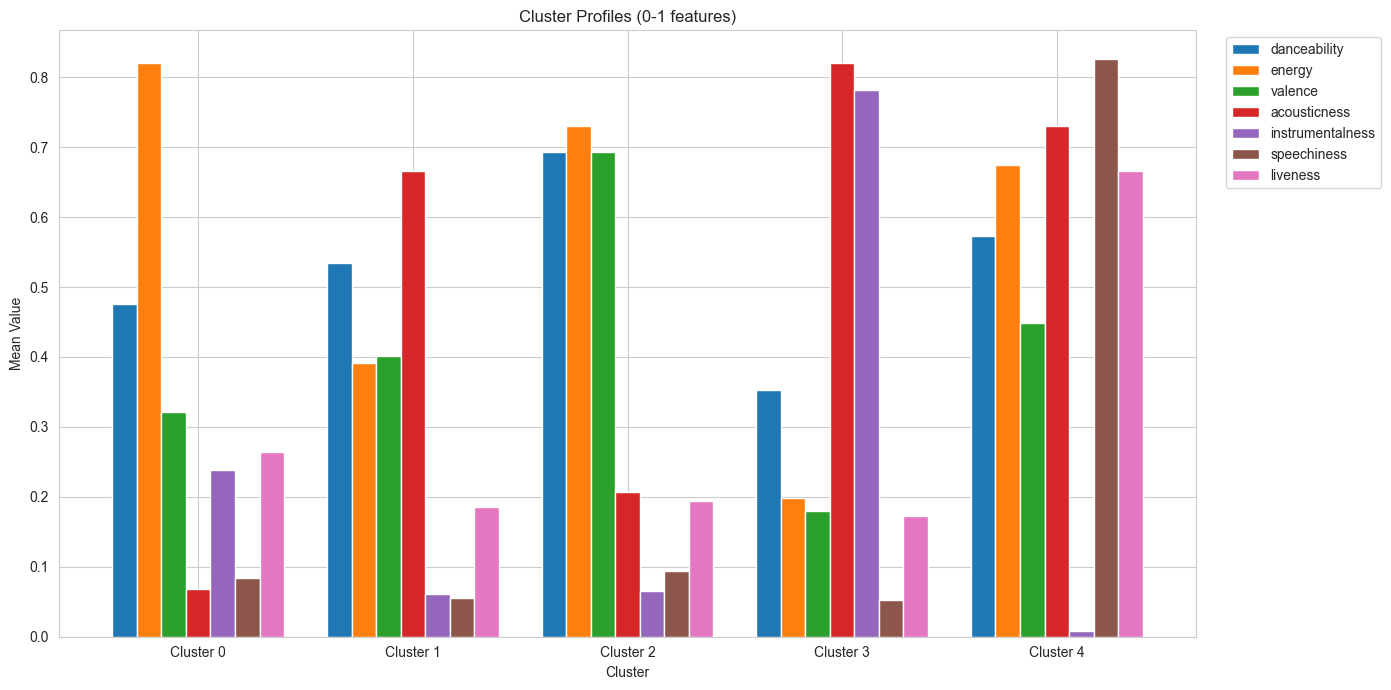

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))
features_01 = ['danceability', 'energy', 'valence', 'acousticness', 
               'instrumentalness', 'speechiness', 'liveness']

df.groupby('cluster')[features_01].mean().plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Cluster Profiles (0-1 features)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Mean Value')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels([f'Cluster {i}' for i in range(5)], rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/fig12_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Noah\AppData\Local\Temp\ipykernel_14312\2742870769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='loudness', palette=clusterColors, ax=axes[0])
C:\Users\Noah\AppData\Local\Temp\ipykernel_14312\2742870769.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='tempo', palette=clusterColors, ax=axes[1])


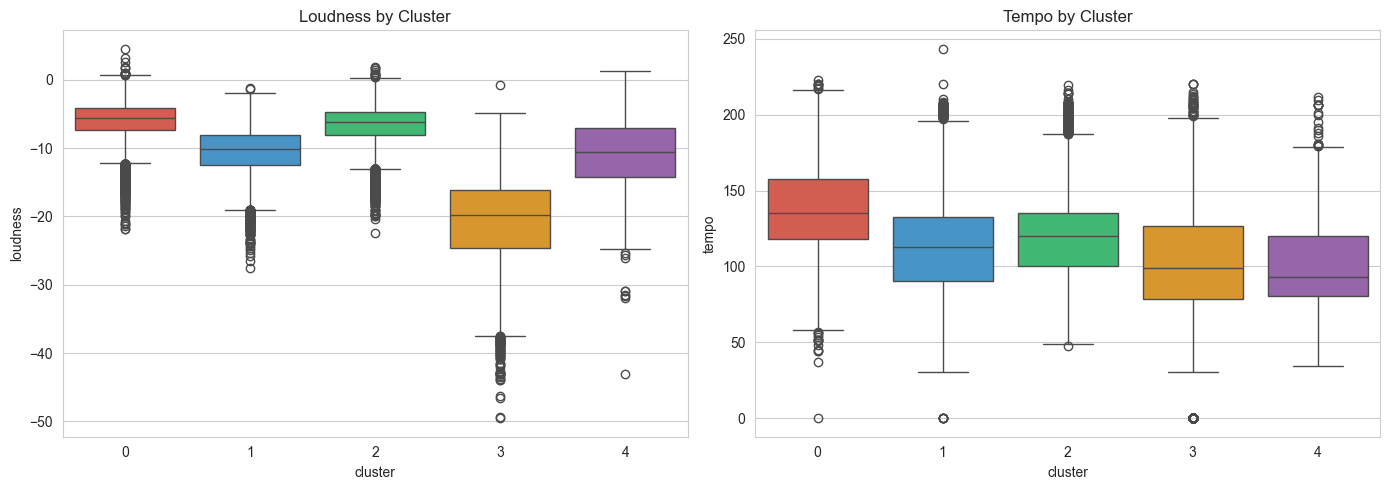

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='cluster', y='loudness', palette=clusterColors, ax=axes[0])
axes[0].set_title('Loudness by Cluster')

sns.boxplot(data=df, x='cluster', y='tempo', palette=clusterColors, ax=axes[1])
axes[1].set_title('Tempo by Cluster')

plt.tight_layout()
plt.savefig('../outputs/figures/fig13_loudness_tempo.png', dpi=150, bbox_inches='tight')
plt.show()


### what's in each cluster?


In [31]:
for c in range(5):
    profile = df[df['cluster'] == c][clustering_features].mean()
    n = len(df[df['cluster'] == c])
    top_g = df[df['cluster'] == c]['track_genre'].value_counts().head(5)
    
    print(f"\n--- Cluster {c} (n={n:,}) ---")
    print(f"  dance={profile['danceability']:.3f}  energy={profile['energy']:.3f}  valence={profile['valence']:.3f}")
    print(f"  acoustic={profile['acousticness']:.3f}  instrumental={profile['instrumentalness']:.3f}")
    print(f"  speech={profile['speechiness']:.3f}  live={profile['liveness']:.3f}")
    print(f"  loudness={profile['loudness']:.1f}dB  tempo={profile['tempo']:.0f}BPM")
    print(f"  top genres: {', '.join(top_g.index.tolist())}")



--- Cluster 0 (n=26,856) ---
  dance=0.476  energy=0.821  valence=0.322
  acoustic=0.068  instrumental=0.238
  speech=0.084  live=0.264
  loudness=-6.0dB  tempo=136BPM
  top genres: grindcore, black-metal, death-metal, heavy-metal, happy

--- Cluster 1 (n=20,830) ---
  dance=0.535  energy=0.391  valence=0.402
  acoustic=0.666  instrumental=0.062
  speech=0.056  live=0.186
  loudness=-10.5dB  tempo=114BPM
  top genres: tango, honky-tonk, cantopop, romance, acoustic

--- Cluster 2 (n=33,656) ---
  dance=0.693  energy=0.730  valence=0.693
  acoustic=0.207  instrumental=0.065
  speech=0.093  live=0.194
  loudness=-6.5dB  tempo=121BPM
  top genres: salsa, dancehall, forro, kids, chicago-house

--- Cluster 3 (n=7,296) ---
  dance=0.353  energy=0.198  valence=0.179
  acoustic=0.821  instrumental=0.781
  speech=0.052  live=0.172
  loudness=-20.7dB  tempo=103BPM
  top genres: sleep, new-age, ambient, classical, iranian

--- Cluster 4 (n=1,102) ---
  dance=0.573  energy=0.674  valence=0.448
  a

each cluster has a distinct profile. you can see clear differences — one is very acoustic/instrumental, another is loud and energetic, etc. the top genres in each cluster make sense with the audio profiles.


### genre purity — do clusters match genre labels?


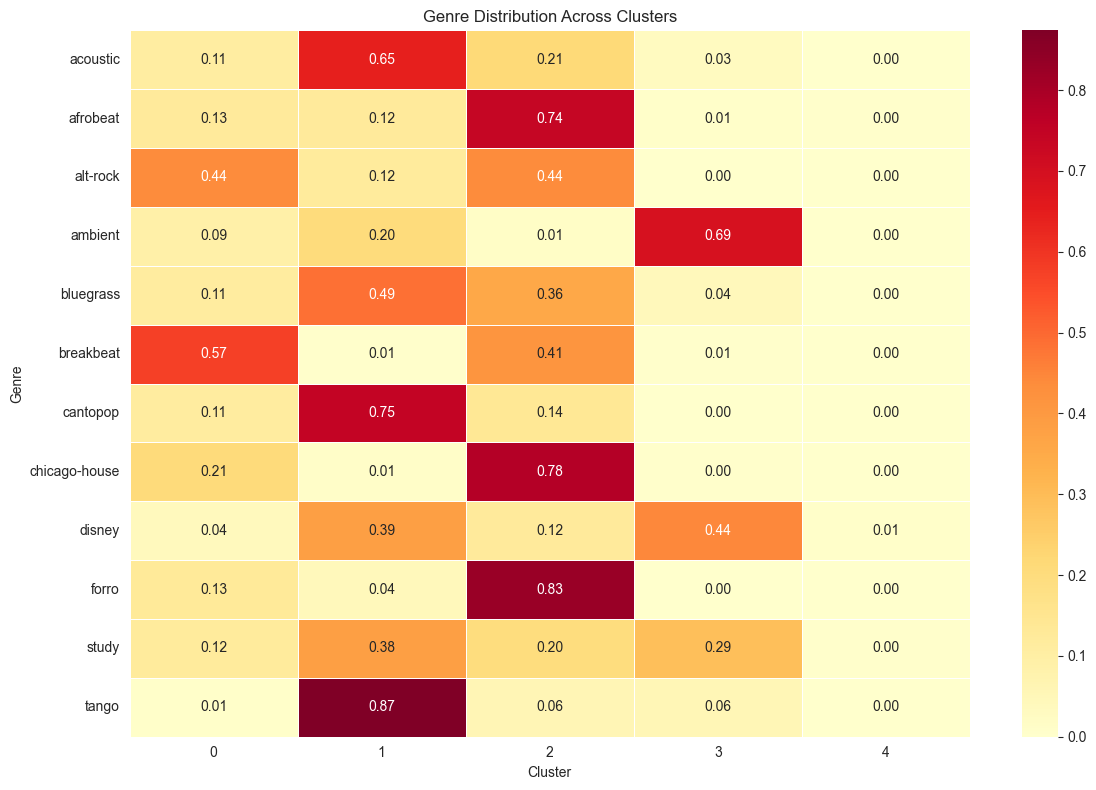

In [32]:
top12 = df['track_genre'].value_counts().head(12).index
df_top12 = df[df['track_genre'].isin(top12)]

ct = pd.crosstab(df_top12['track_genre'], df_top12['cluster'], normalize='index').round(3)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Genre Distribution Across Clusters')
ax.set_xlabel('Cluster')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('../outputs/figures/fig14_genre_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


genres don't map cleanly to clusters. most genres are spread across multiple clusters. this confirms what we expected — audio-based clustering reveals patterns that cross genre boundaries. pop and electronic end up in similar clusters because they sound similar even though they're labeled differently.


## 6. Findings

**primary question — what clusters emerge?**
5 distinct sonic archetypes. each has a clear audio profile and the top genres in each cluster make sense. see the profiling above for details.

**supporting question — latent dimensions?**
PCA shows the main axis is acoustic vs produced (energy/loudness vs acousticness). second axis is more about danceability/valence.

**surprises:** pop and electronic overlap a lot. the acoustic cluster is really cohesive.

**limitations:** k-means assumes spherical clusters, k=5 is somewhat arbitrary, audio features miss lyrical/cultural aspects of genre.

**for M3:** try DBSCAN, train decision trees on cluster labels for interpretable rules, group the 114 genres into broader families.


In [33]:
print(f"done. {len(df):,} tracks, {df['track_genre'].nunique()} genres, 5 clusters")


done. 89,740 tracks, 113 genres, 5 clusters


---
## scratch work / experiments


In [34]:
# tried k=3 first but the clusters were too broad
# km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
# labels3 = km3.fit_predict(X_scaled)
# print(f"k=3 silhouette: {silhouette_score(X_scaled, labels3, sample_size=10000, random_state=42):.4f}")
# print(pd.Series(labels3).value_counts().sort_index())
# the silhouette was higher but 3 groups is too few to see anything interesting


In [35]:
# TODO: try DBSCAN for M3
# from sklearn.cluster import DBSCAN
# db = DBSCAN(eps=1.5, min_samples=10)
# db_labels = db.fit_predict(X_scaled)
# print(f"DBSCAN found {len(set(db_labels)) - (1 if -1 in db_labels else 0)} clusters")
# print(f"noise points: {(db_labels == -1).sum()}")


In [36]:
# was curious about whether popularity differs by cluster
# print(df.groupby('cluster')['popularity'].describe().round(1))
# not really — popularity is spread out in all clusters


In [37]:
# TODO: decision tree on cluster labels for M3
# from sklearn.tree import DecisionTreeClassifier, export_text
# dt = DecisionTreeClassifier(max_depth=4, random_state=42)
# dt.fit(X_scaled, df['cluster'])
# print(export_text(dt, feature_names=clustering_features))


In [38]:
print("hello")

hello
